# CNN Training, Experiment, and Evaluations


Intel Image Classification using Shared and Non-Shared Convolutional Architectures

## Clone Repository

In [ ]:
# CLONE REPO
!git clone https://github.com/dasarpemrograman/Tubes2_CNNRNN.git
%cd Tubes2_CNNRNN

In [30]:
%cd Tubes2_CNNRNN

/content/Tubes2_CNNRNN


In [33]:
!pwd
!ls

/content/Tubes2_CNNRNN
artifacts			kaggle.json	README.md  seg_test   tests
doc				plan.md		scripts    seg_train  uv.lock
intel-image-classification.zip	pyproject.toml	seg_pred   src


## Install UV dan Dependencies

In [34]:
!curl -LsSf https://astral.sh/uv/install.sh | sh

downloading uv 0.11.14 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!


In [35]:
import os
os.environ["PATH"] += ":/root/.local/bin"

In [36]:
!uv sync

Resolved 139 packages in 1ms
Checked 135 packages in 2ms


## Setup Kaggle

In [38]:
import json

kaggle_info = {
    "username": "USERNAME",
    "key": "API_KEY"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_info, f)

In [39]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle

## Dataset

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

In [41]:
!rm -rf seg_train seg_test seg_pred

In [42]:
!unzip -oq intel-image-classification.zip

In [43]:
!mv seg_train/seg_train/* seg_train/
!mv seg_test/seg_test/* seg_test/
!rmdir seg_train/seg_train
!rmdir seg_test/seg_test

In [45]:
!uv run python src/cnn/preprocessing.py \
  --dataset-root /content/Tubes2_CNNRNN \
  --output artifacts/cnn/dataset_index.csv \
  --labels-output artifacts/cnn/labels.json \
  --smoke-load

Loaded batch shape=(32, 150, 150, 3) dtype=float32 range=(0.0, 1.0)
Wrote 17034 indexed images to artifacts/cnn/dataset_index.csv
Wrote labels to artifacts/cnn/labels.json


In [46]:
!pwd

/content/Tubes2_CNNRNN


In [47]:
import pandas as pd

df_index = pd.read_csv("artifacts/cnn/dataset_index.csv")
print(df_index["split"].value_counts())

split
train    14034
test      3000
Name: count, dtype: int64


In [48]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Train 16 Arsitektur Conv2D

In [49]:
!uv run python src/experiments/train_cnn.py \
  --epochs 5 \
  --image-size 64x64 \
  --batch-size 32 \
  --force

W0000 00:00:1778849835.154473   17243 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
Epoch 1/5
351/351 - 29s - 84ms/step - accuracy: 0.6150 - loss: 1.0141 - val_accuracy: 0.7121 - val_loss: 0.7944
Epoch 2/5
351/351 - 16s - 45ms/step - accuracy: 0.7406 - loss: 0.7298 - val_accuracy: 0.7517 - val_loss: 0.6995
Epoch 3/5
351/351 - 15s - 43ms/step - accuracy: 0.7891 - loss: 0.5850 - val_accuracy: 0.7720 - val_loss: 0.6325
Epoch 4/5
351/351 - 15s - 43ms/step - accuracy: 0.8276 - loss: 0.4893 - val_accuracy: 0.7649 - val_loss: 0.6458
Epoch 5/5
351/351 - 15s - 43ms/step - accuracy: 0.8590 - loss: 0.3928 - val_accuracy: 0.7905 - val_loss: 0.6097
Epoch 1/5
351/351 - 21s - 60ms/step - accuracy: 0.5937 - loss: 1.0617 - val_accuracy: 0.6936 - val_loss: 0.8321
Epoch 2/5
351/351 - 15s - 42ms/step - accuracy: 0.6946 - loss: 0.8336 - val_accuracy: 0.7271 - val_loss: 0.7556
Epoch 3/5
351/351 - 15s

In [50]:
!uv run python src/experiments/evaluate_cnn.py aggregate

Aggregated 17 shared Conv2D result(s).


In [55]:
import pandas as pd

df_rank = pd.read_csv("artifacts/cnn/metrics/ranked_results.csv")
df_rank = df_rank.drop_duplicates(subset="model_id", keep="first").reset_index(drop=True)
df_rank[["model_id", "test_macro_f1"]]

,model_id,test_macro_f1
0,cnn_c3_f64-128-256_k3-3-3_max,0.809704
1,cnn_c3_f32-64-128_k3-3-3_max,0.802378
2,cnn_c3_f32-64-128_k5-3-3_max,0.799850
3,cnn_c3_f64-128-256_k5-3-3_max,0.794856
4,cnn_c3_f32-64-128_k3-3-3_average,0.785975
5,cnn_c2_f32-64_k3-3_max,0.781911
6,cnn_c3_f64-128-256_k5-3-3_average,0.780810
7,cnn_c3_f64-128-256_k3-3-3_average,0.778036
8,cnn_c2_f64-128_k3-3_max,0.777246
9,cnn_c2_f64-128_k5-3_max,0.772484


## Perbandingan Hasil Training

In [51]:
!uv run python src/experiments/evaluate_cnn.py keras-vs-scratch

W0000 00:00:1778851855.745589   28494 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
Keras vs scratch metrics: {'model_id': 'cnn_c3_f64-128-256_k3-3-3_max', 'keras_macro_f1': 0.8097037300279805, 'scratch_macro_f1': 0.8097037300279805, 'prediction_matches': 3000, 'prediction_mismatches': 0, 'total_examples': 3000, 'max_probability_abs_diff': 1.3113021850585938e-06}


### Keras vs Scratch

In [53]:
import json, glob

files = glob.glob("artifacts/cnn/metrics/*keras_vs_scratch.json")
print(files)

with open(files[-1]) as f:
    data_keras_vs_scratch = json.load(f)

data_keras_vs_scratch

['artifacts/cnn/metrics/cnn_c2_f32-64_k3-3_max_keras_vs_scratch.json', 'artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_keras_vs_scratch.json']


{'keras_macro_f1': 0.8097037300279805,
 'max_probability_abs_diff': 1.3113021850585938e-06,
 'model_id': 'cnn_c3_f64-128-256_k3-3-3_max',
 'prediction_matches': 3000,
 'prediction_mismatches': 0,
 'scratch_macro_f1': 0.8097037300279805,
 'total_examples': 3000}

### Shared vs Non Shared

In [56]:
best_model_id = df_rank.iloc[0]["model_id"]
print(best_model_id)

cnn_c3_f64-128-256_k3-3-3_max


In [66]:
!uv run python src/experiments/evaluate_cnn.py shared-vs-non-shared \
  --model-id {best_model_id} \
  --image-size 32x32 \
  --batch-size 8 \
  --epochs 1 \
  --max-train-samples 1000 \
  --max-validation-samples 300 \
  --max-test-samples 300 \
  --force

Selected shared_model_id: cnn_c3_f64-128-256_k3-3-3_max
Selected non_shared_model_id: cnn_c3_f64-128-256_k3-3-3_max_non_shared
W0000 00:00:1778854112.836733   38280 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


In [68]:
!git pull

Already up to date.


In [69]:
!find artifacts/cnn -type f | grep shared

artifacts/cnn/metrics/cnn_c2_f32-64_k3-3_max_non_shared_summary.txt
artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_non_shared_summary.txt
artifacts/cnn/metrics/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/metrics/best_shared_conv2d.json
artifacts/cnn/histories/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/configs/cnn_c3_f64-128-256_k3-3-3_max_non_shared.json
artifacts/cnn/configs/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/predictions/cnn_c2_f32-64_k3-3_max_non_shared_validation.csv
artifacts/cnn/predictions/cnn_c2_f32-64_k3-3_max_non_shared_test.csv
artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max_non_shared.png


In [71]:
!find artifacts/cnn -type f | grep non_shared

artifacts/cnn/metrics/cnn_c2_f32-64_k3-3_max_non_shared_summary.txt
artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_non_shared_summary.txt
artifacts/cnn/metrics/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/histories/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/configs/cnn_c3_f64-128-256_k3-3-3_max_non_shared.json
artifacts/cnn/configs/cnn_c2_f32-64_k3-3_max_non_shared.json
artifacts/cnn/predictions/cnn_c2_f32-64_k3-3_max_non_shared_validation.csv
artifacts/cnn/predictions/cnn_c2_f32-64_k3-3_max_non_shared_test.csv
artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max_non_shared.png


In [73]:
!cat artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_non_shared_summary.txt

Model: "cnn_c3_f64-128-256_k3-3-3_max_non_shared"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_1           │ (None, 32, 32, 64)     │     1,835,008 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_2           │ (None, 16, 16, 128)    │    18,907,136 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────

In [74]:
import pandas as pd

df_rank_new = pd.read_csv("artifacts/cnn/metrics/ranked_results.csv")
df_rank_new = df_rank_new.drop_duplicates(subset="model_id")

best_shared = df_rank_new[df_rank_new["model_id"] == "cnn_c3_f64-128-256_k3-3-3_max"]

best_shared[[
    "model_id",
    "parameter_count",
    "test_macro_f1",
    "validation_macro_f1"
]]

,model_id,parameter_count,test_macro_f1,validation_macro_f1
0,cnn_c3_f64-128-256_k3-3-3_max,2468870,0.809704,0.810351


In [5]:
import os
os.getcwd()

'd:\\JELITA\\182-6\\ML\\Tubes 2\\Tubes2_CNNRNN\\src\\notebooks'

In [7]:
with open("../../artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_summary.txt", encoding="utf-8") as f:
    print(f.read())

Model: "cnn_c3_f64-128-256_k3-3-3_max"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼──

In [75]:
with open("artifacts/cnn/metrics/cnn_c3_f64-128-256_k3-3-3_max_non_shared_summary.txt") as f:
    print(f.read())

Model: "cnn_c3_f64-128-256_k3-3-3_max_non_shared"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_1           │ (None, 32, 32, 64)     │     1,835,008 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_2           │ (None, 16, 16, 128)    │    18,907,136 │
│ (LocallyConnected2D)            │                        │               │
├─────────────────────────

## Analisis Hyperparameter

In [76]:
df_analyze = pd.read_csv("artifacts/cnn/metrics/ranked_results.csv")
df_analyze = df_analyze.drop_duplicates(subset="model_id")

df_analyze["conv_layers"] = df_analyze["model_id"].str.extract(r'c(\d+)').astype(int)

df_analyze.groupby("conv_layers")["test_macro_f1"].agg(["mean", "max", "count"])

,mean,max,count
conv_layers,,,
2,0.765608,0.781911,8
3,0.787185,0.809704,8


In [79]:
# Pengaruh jumlah filter
df_analyze["filters"] = df_analyze["model_id"].str.extract(r'_(f[^_]+)_')

df_analyze.groupby("filters")["test_macro_f1"].agg(["mean", "max", "count"])

,mean,max,count
filters,,,
f32-64,0.763098,0.781911,4
f32-64-128,0.783518,0.802378,4
f64-128,0.768118,0.777246,4
f64-128-256,0.790851,0.809704,4


In [81]:
# pengaruh kernel size
df_analyze["kernel_size"] = df_analyze["model_id"].str.extract(r'_(k[^_]+)_')

df_analyze.groupby("kernel_size")["test_macro_f1"].agg(["mean", "max", "count"])

,mean,max,count
kernel_size,,,
k3-3,0.773447,0.781911,4
k3-3-3,0.794023,0.809704,4
k5-3,0.757769,0.772484,4
k5-3-3,0.780346,0.799850,4


In [82]:
# Pengaruh pooling
df_analyze["pooling"] = df_analyze["model_id"].str.extract(r'_(max|average)$')

df_analyze.groupby("pooling")["test_macro_f1"].agg(["mean", "max", "count"])

,mean,max,count
pooling,,,
average,0.764837,0.785975,8
max,0.787956,0.809704,8


In [83]:
!find artifacts/cnn/plots -type f

artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_max.png
artifacts/cnn/plots/cnn_c2_f32-64_k5-3_average.png
artifacts/cnn/plots/cnn_c2_f64-128_k5-3_average.png
artifacts/cnn/plots/cnn_c2_f64-128_k3-3_average.png
artifacts/cnn/plots/cnn_c3_f64-128-256_k3-3-3_average.png
artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max_non_shared.png
artifacts/cnn/plots/cnn_c2_f64-128_k3-3_max.png
artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max.png
artifacts/cnn/plots/cnn_c2_f64-128_k5-3_max.png
artifacts/cnn/plots/cnn_c3_f32-64-128_k3-3-3_max.png
artifacts/cnn/plots/cnn_c2_f32-64_k5-3_max.png
artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_average.png
artifacts/cnn/plots/cnn_c3_f32-64-128_k5-3-3_average.png
artifacts/cnn/plots/cnn_c3_f32-64-128_k3-3-3_average.png
artifacts/cnn/plots/cnn_c2_f32-64_k3-3_average.png
artifacts/cnn/plots/cnn_c3_f32-64-128_k5-3-3_max.png
artifacts/cnn/plots/cnn_c3_f64-128-256_k3-3-3_max.png


artifacts/cnn/plots/cnn_c2_f32-64_k3-3_average.png


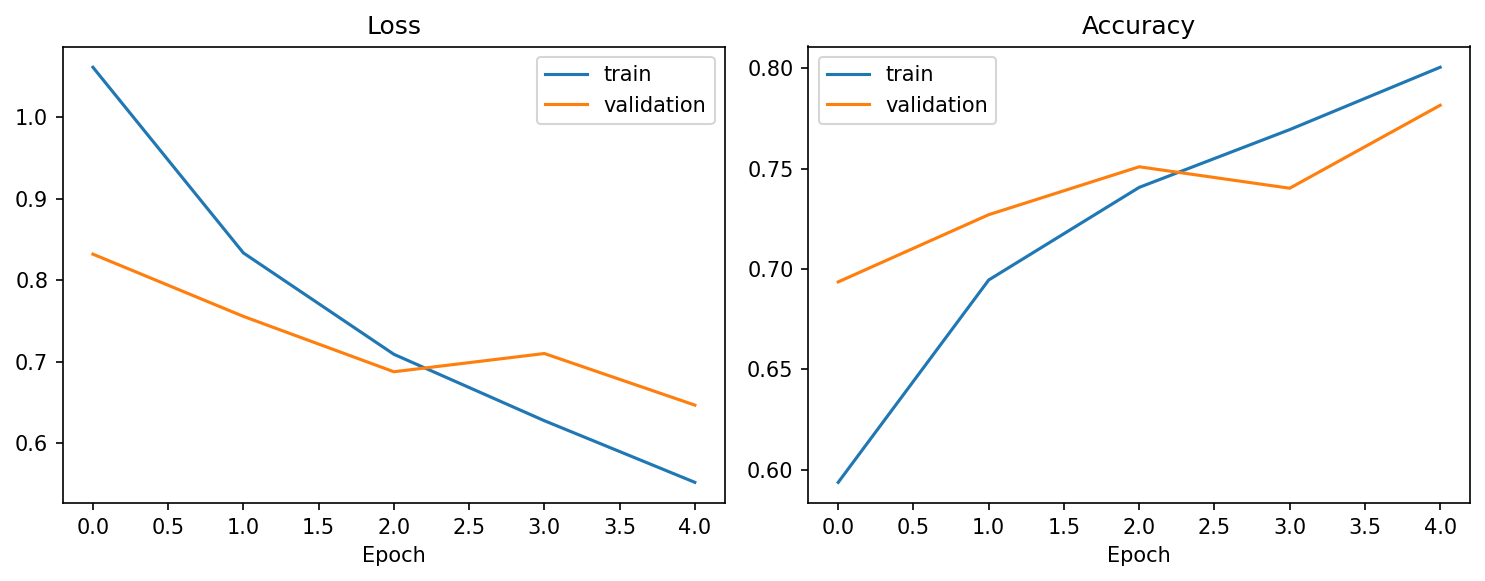

artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max.png


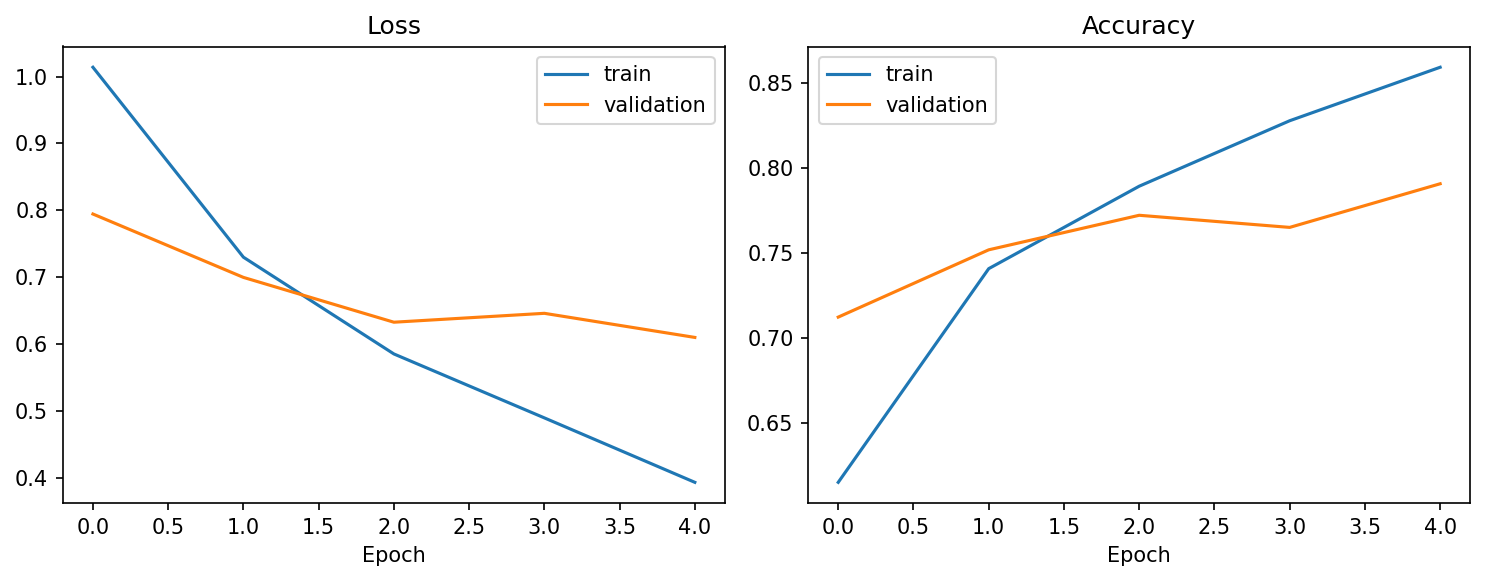

artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max_non_shared.png


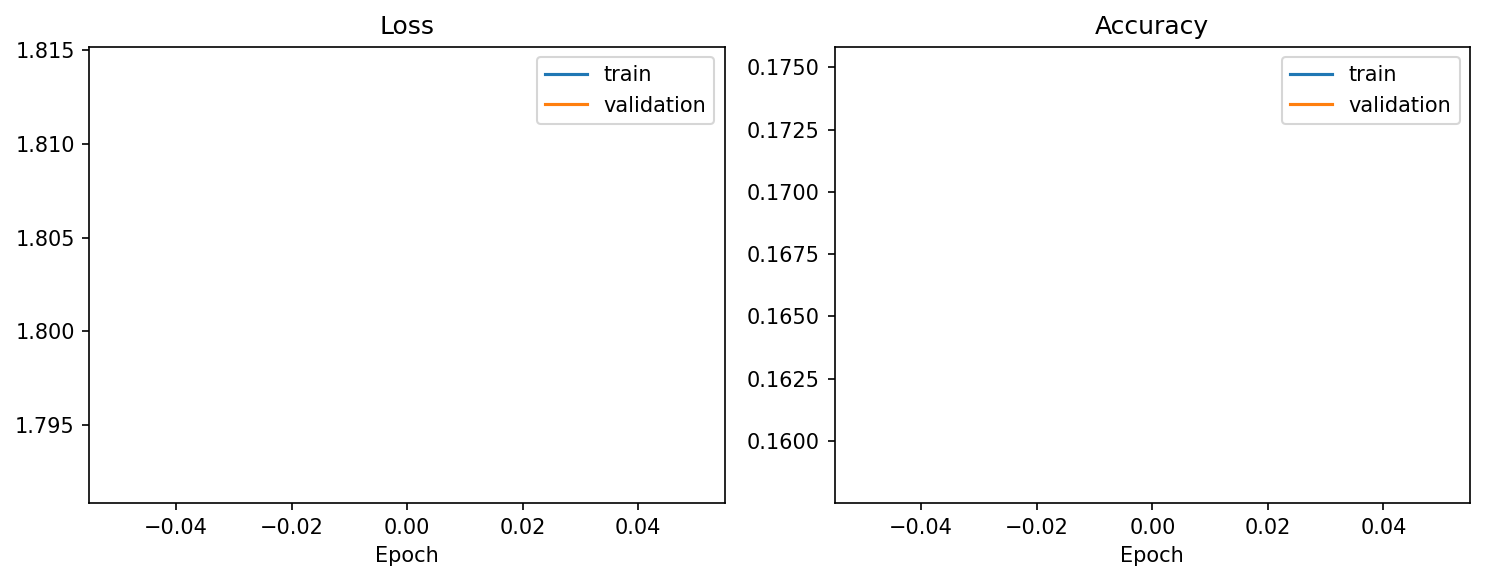

artifacts/cnn/plots/cnn_c2_f32-64_k5-3_average.png


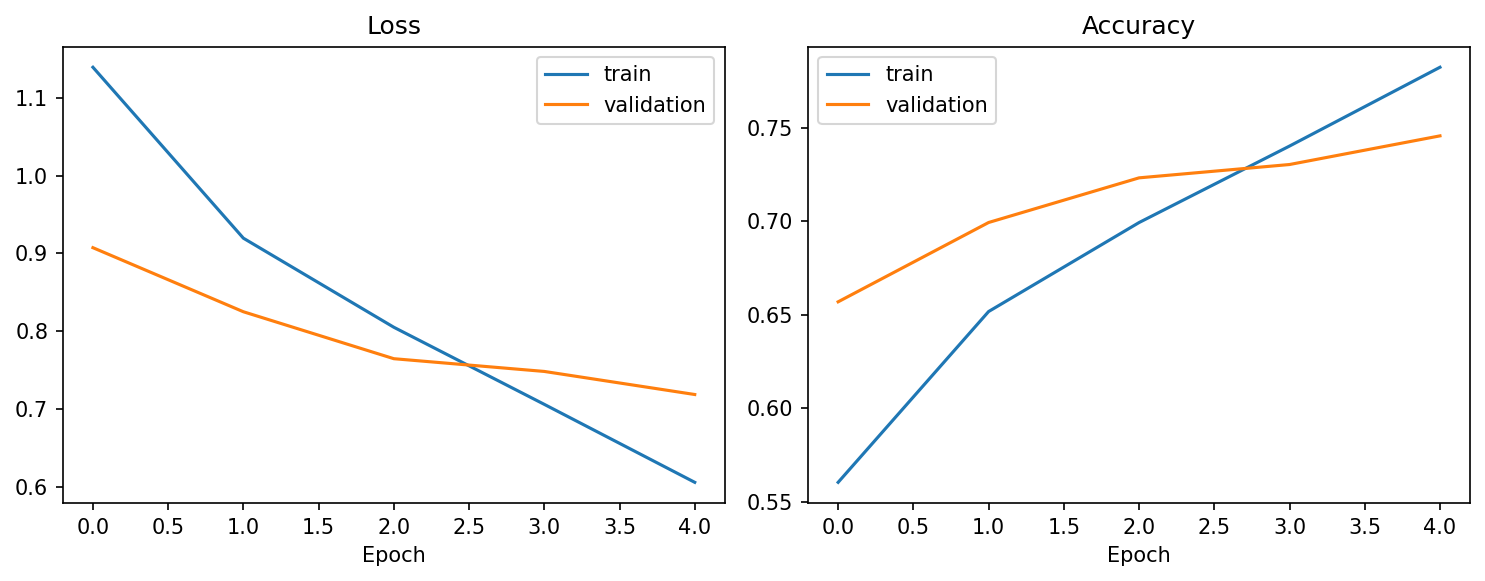

artifacts/cnn/plots/cnn_c2_f32-64_k5-3_max.png


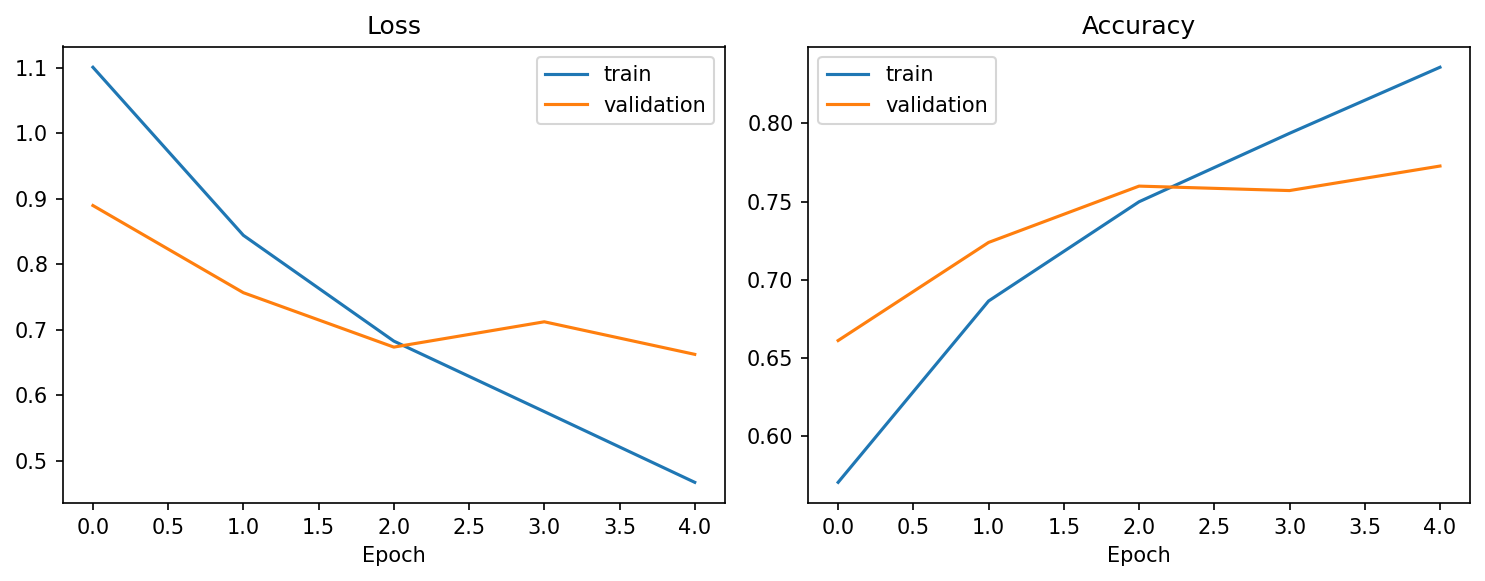

artifacts/cnn/plots/cnn_c2_f64-128_k3-3_average.png


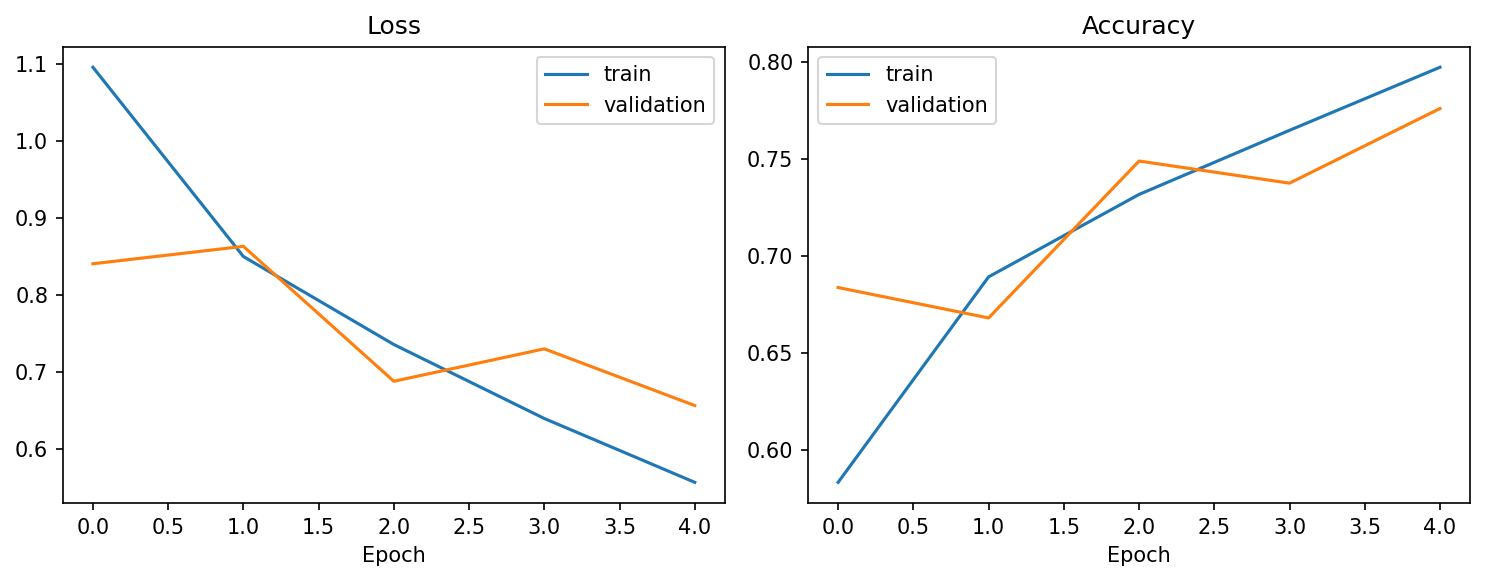

artifacts/cnn/plots/cnn_c2_f64-128_k3-3_max.png


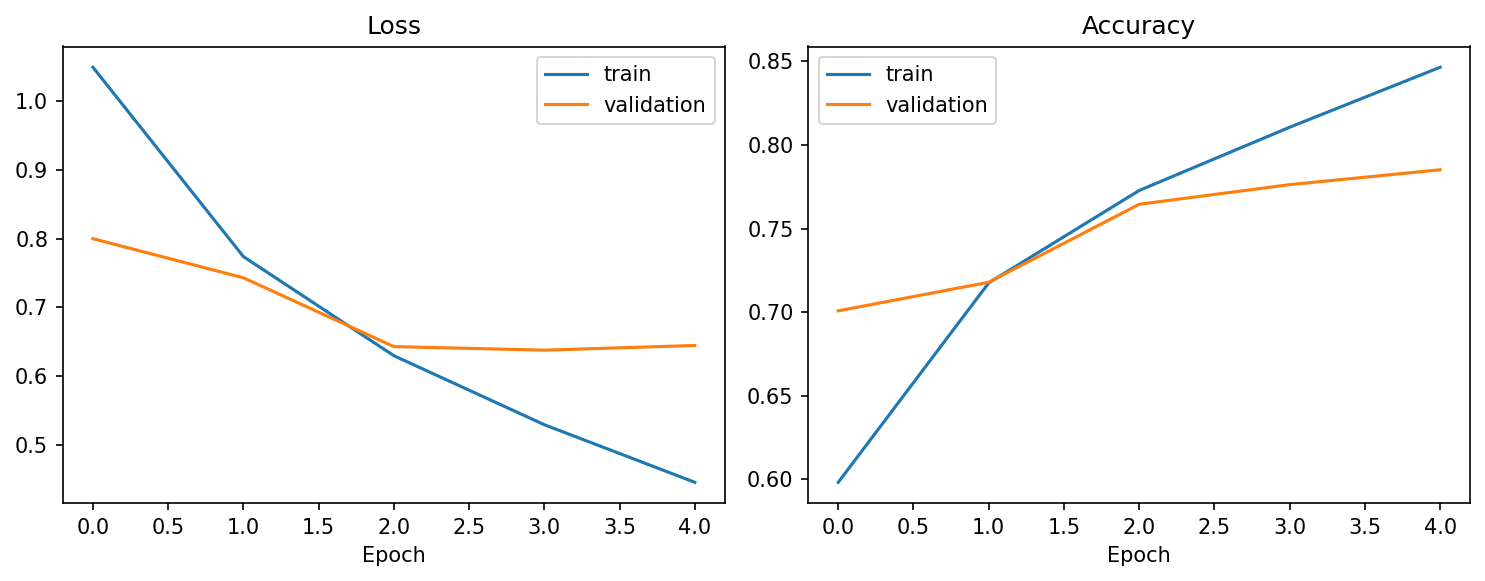

artifacts/cnn/plots/cnn_c2_f64-128_k5-3_average.png


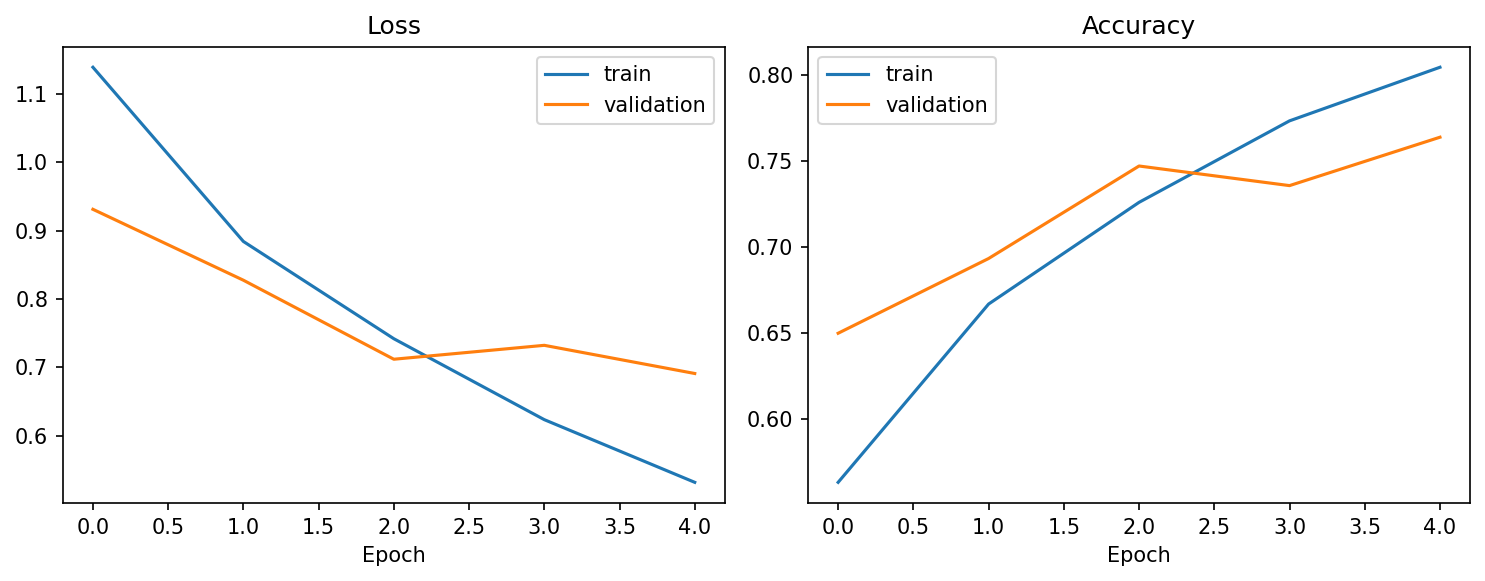

artifacts/cnn/plots/cnn_c2_f64-128_k5-3_max.png


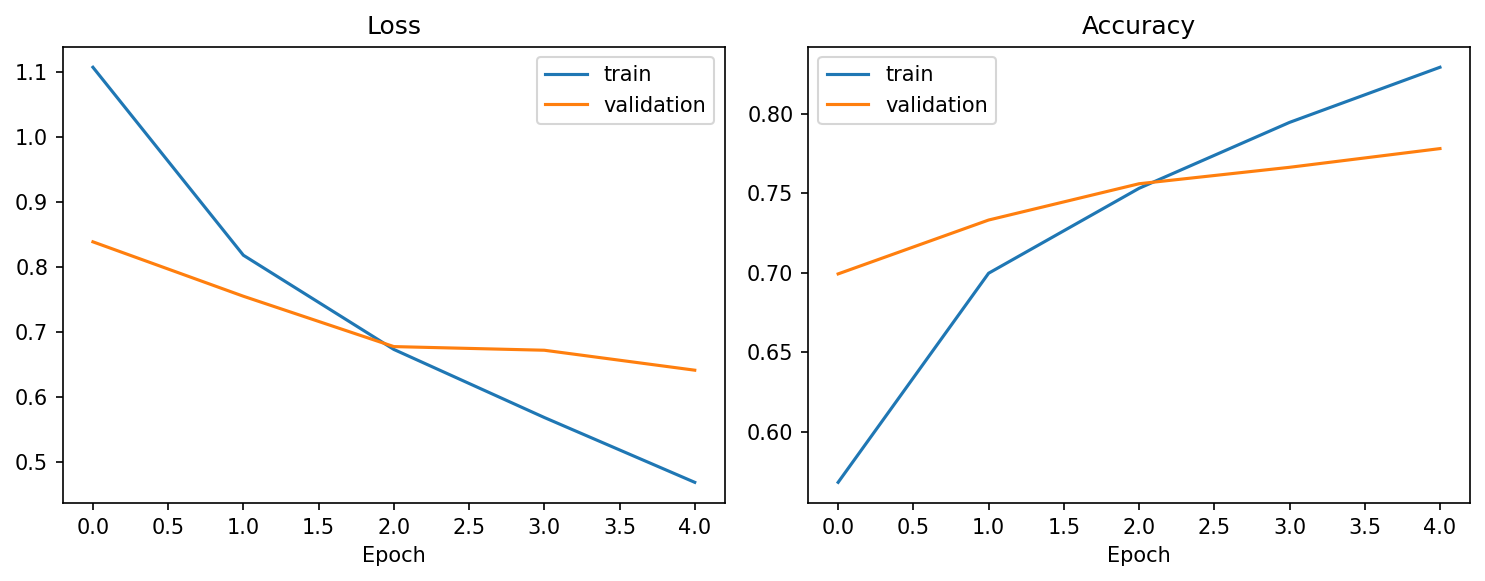

artifacts/cnn/plots/cnn_c3_f32-64-128_k3-3-3_average.png


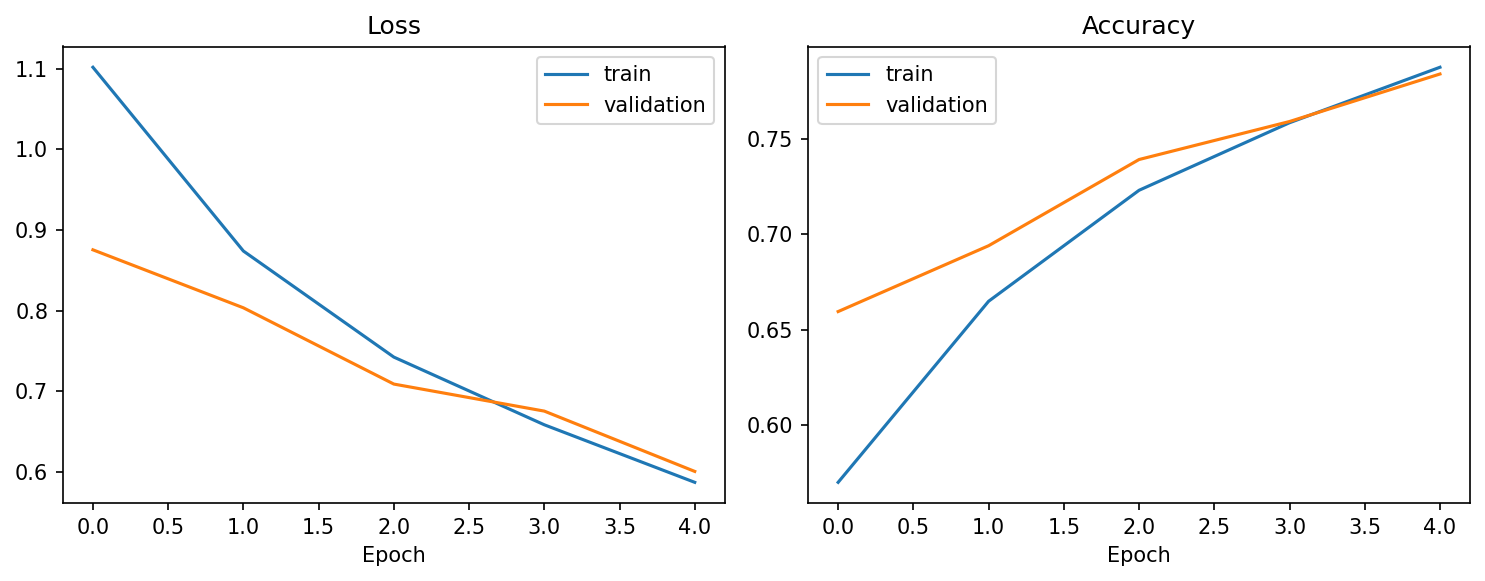

artifacts/cnn/plots/cnn_c3_f32-64-128_k3-3-3_max.png


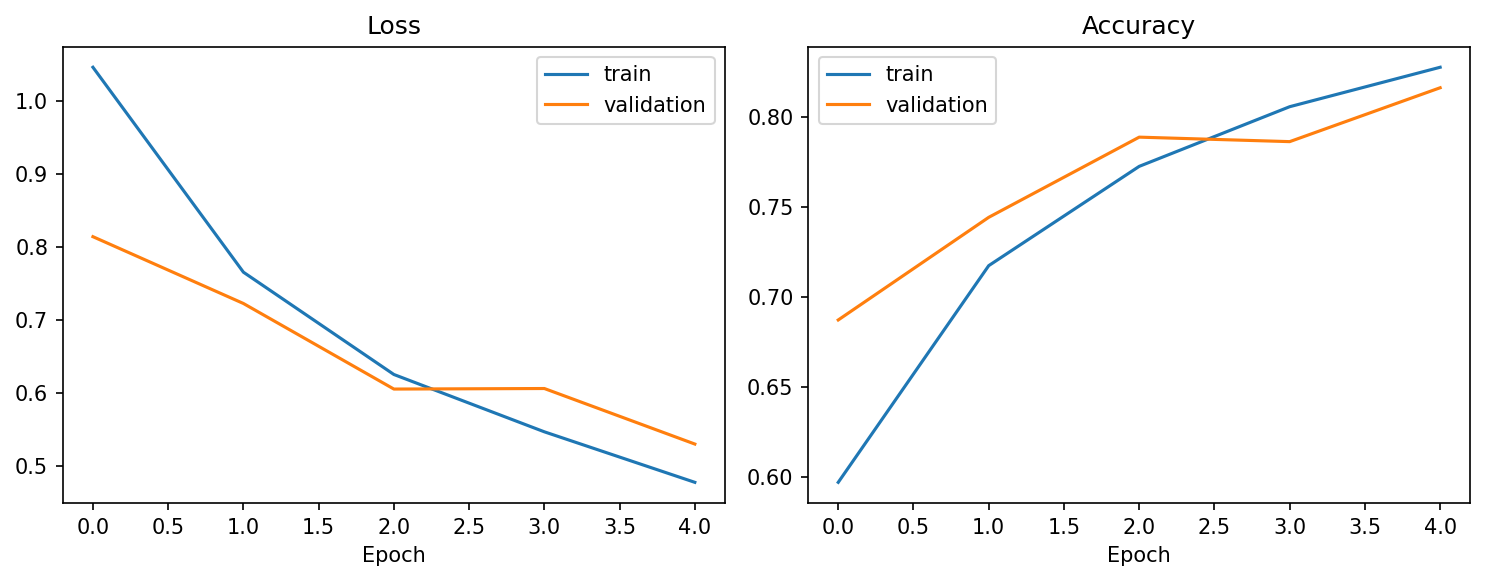

artifacts/cnn/plots/cnn_c3_f32-64-128_k5-3-3_average.png


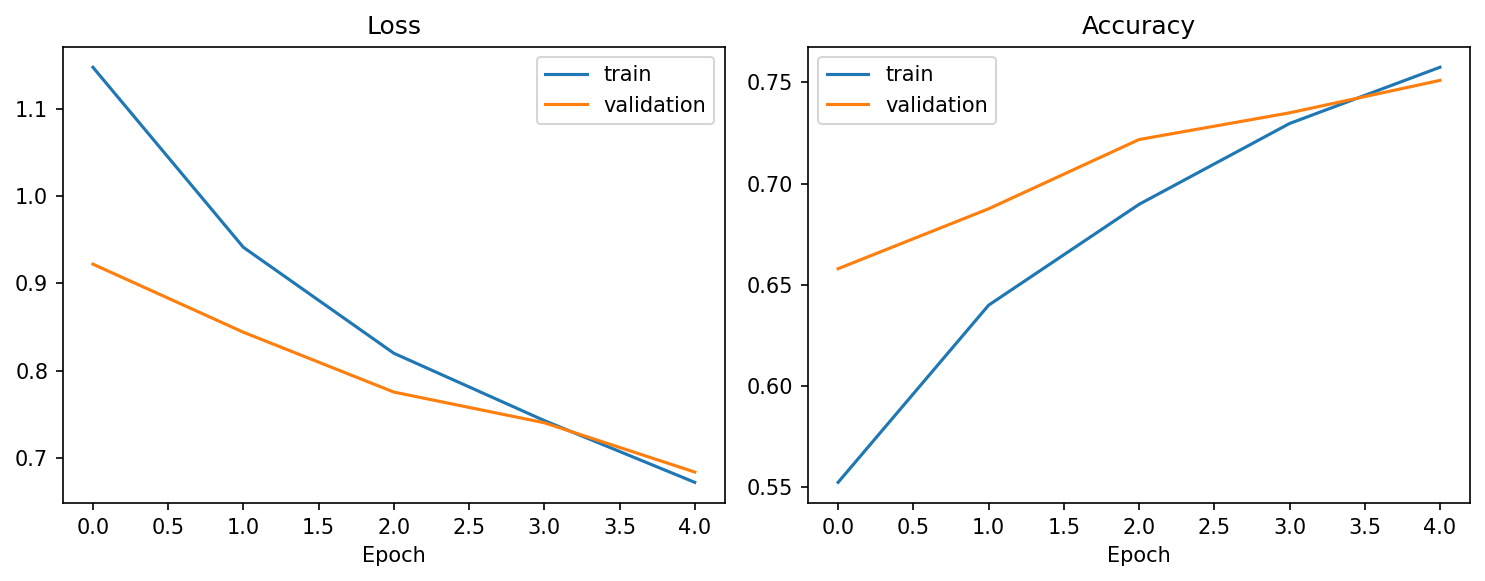

artifacts/cnn/plots/cnn_c3_f32-64-128_k5-3-3_max.png


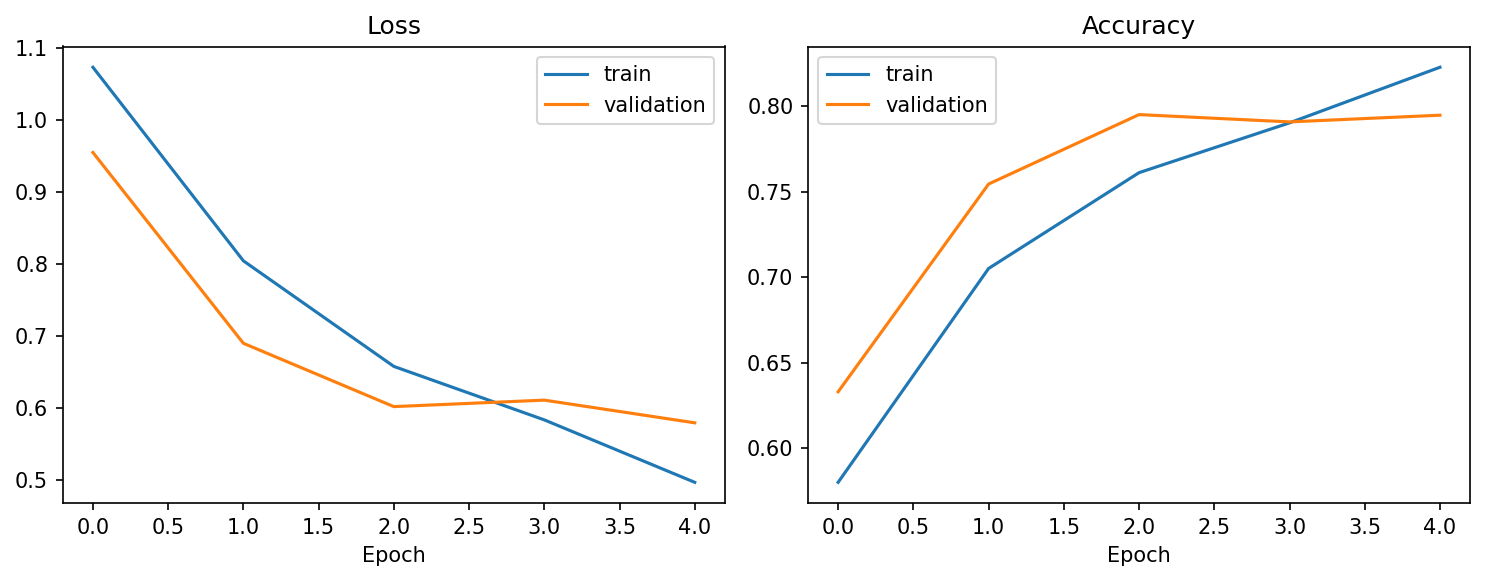

artifacts/cnn/plots/cnn_c3_f64-128-256_k3-3-3_average.png


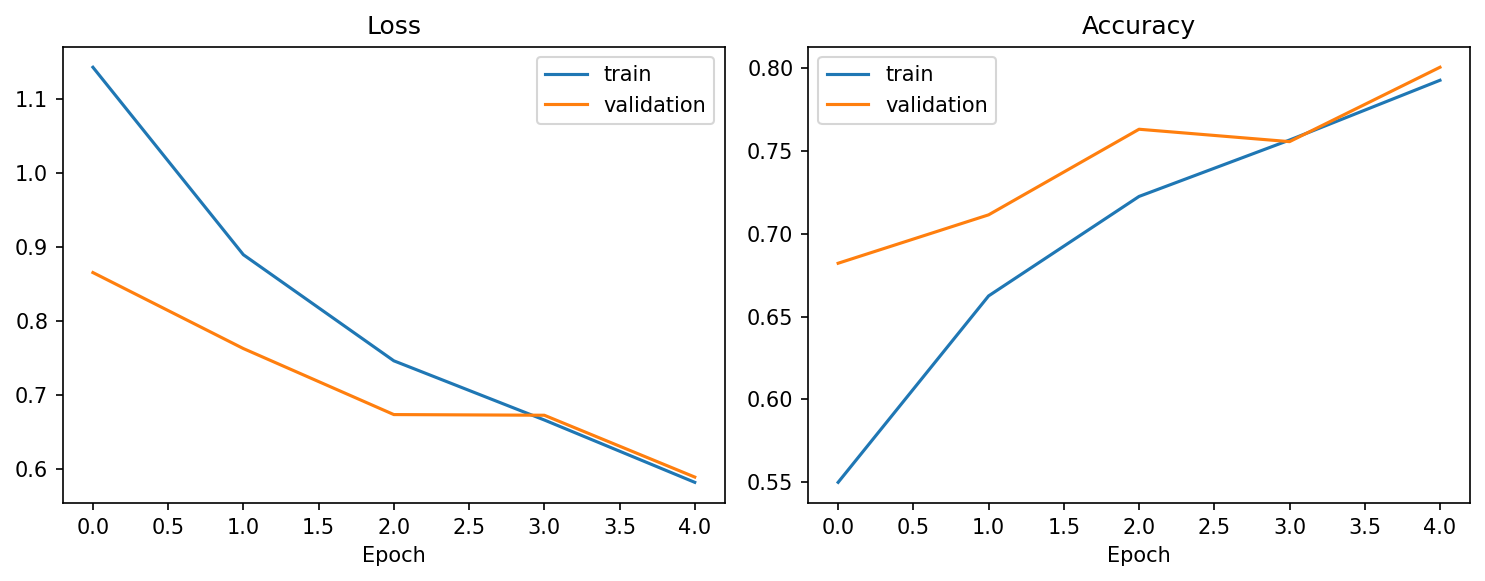

artifacts/cnn/plots/cnn_c3_f64-128-256_k3-3-3_max.png


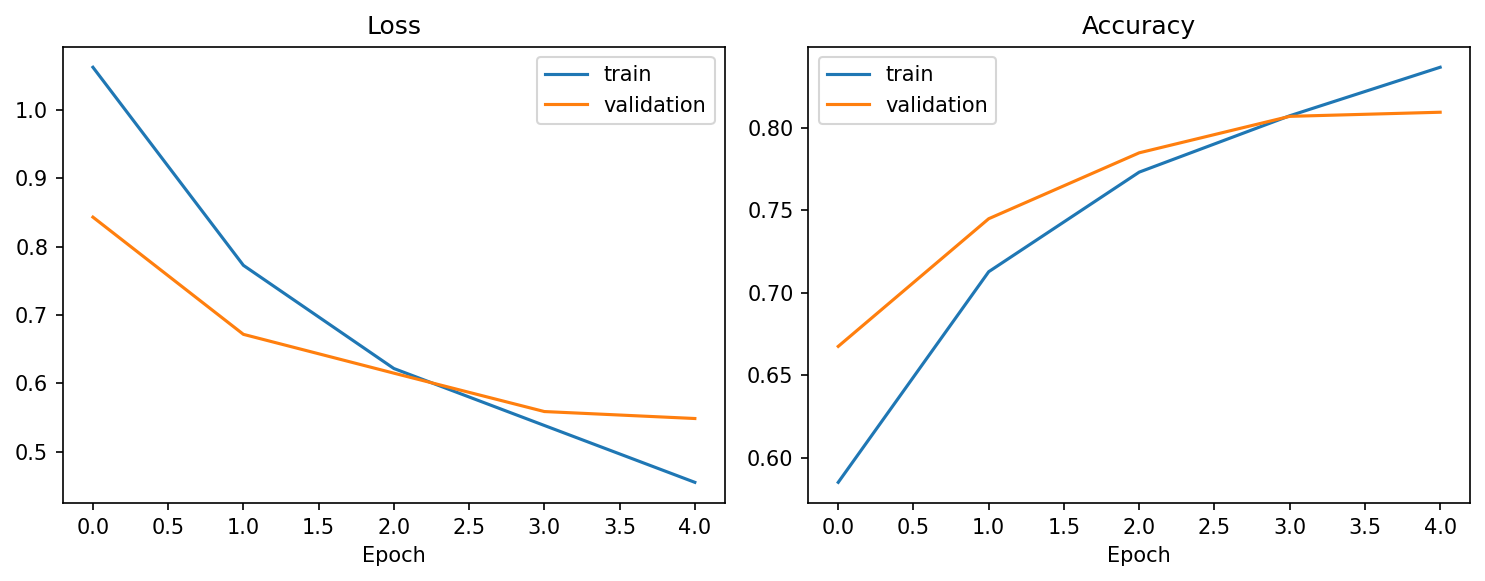

artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_average.png


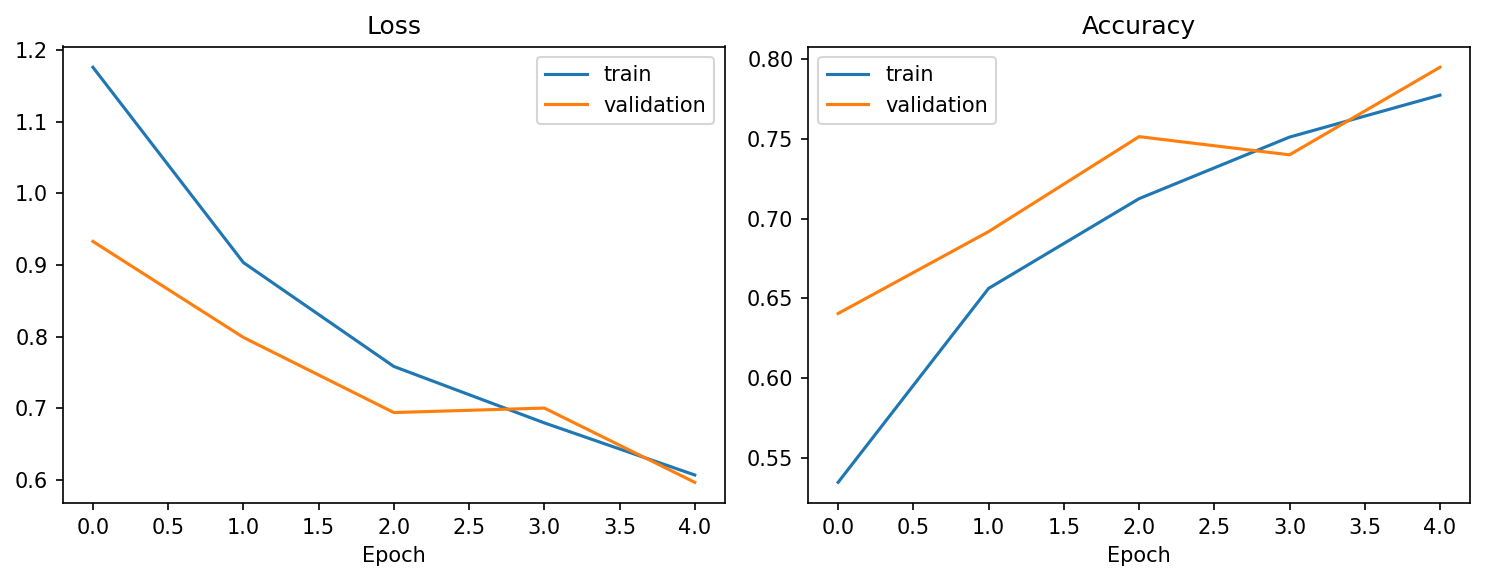

artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_max.png


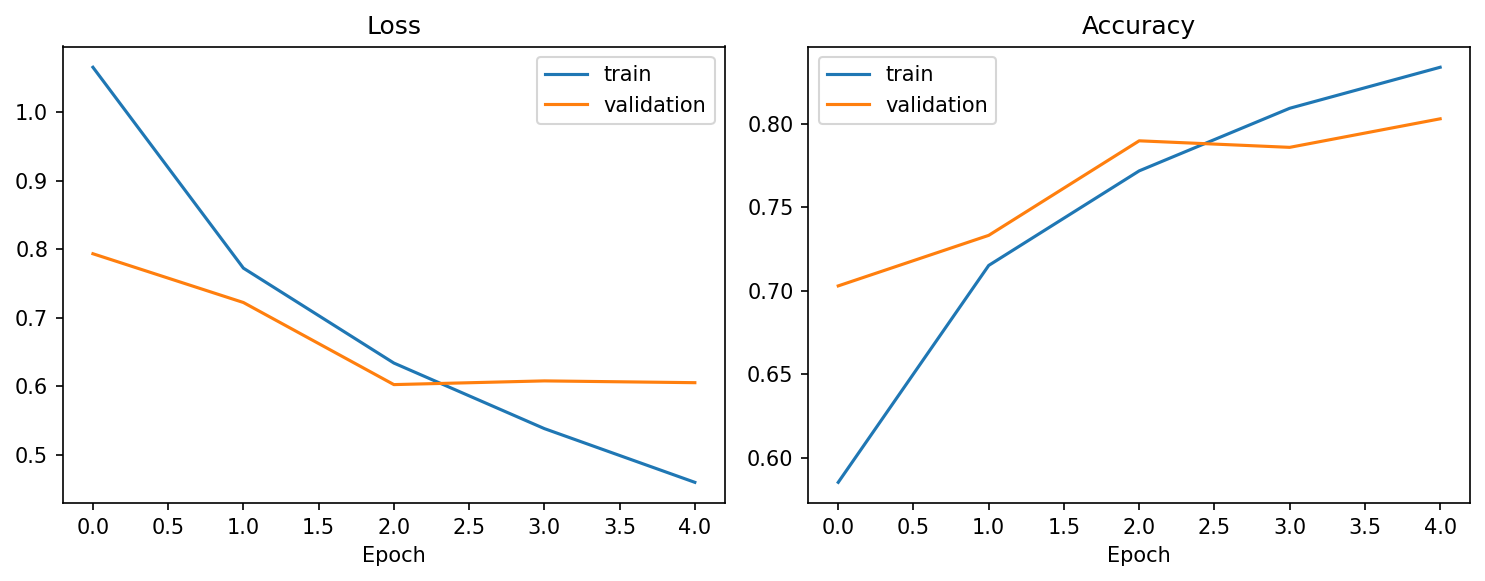

In [88]:
from IPython.display import Image, display
import glob

plot_files = sorted(glob.glob("artifacts/cnn/plots/*.png"))

for path in plot_files:
    print(path)
    display(Image(filename=path))

In [89]:
import json

with open("artifacts/cnn/histories/cnn_c2_f32-64_k3-3_max_non_shared.json") as f:
    hist = json.load(f)

hist

{'accuracy': [0.1666666716337204],
 'loss': [1.814088225364685],
 'val_accuracy': [0.1666666716337204],
 'val_loss': [1.791943073272705]}

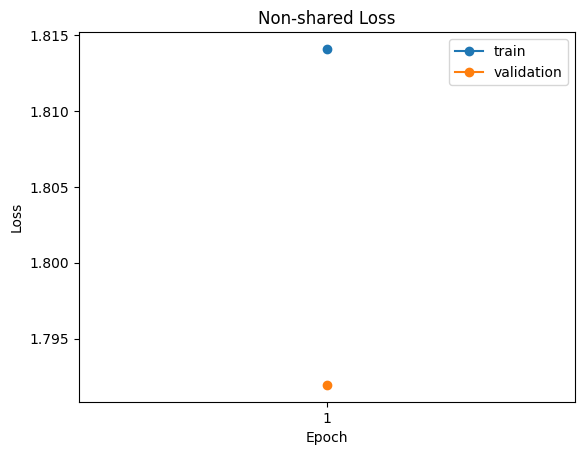

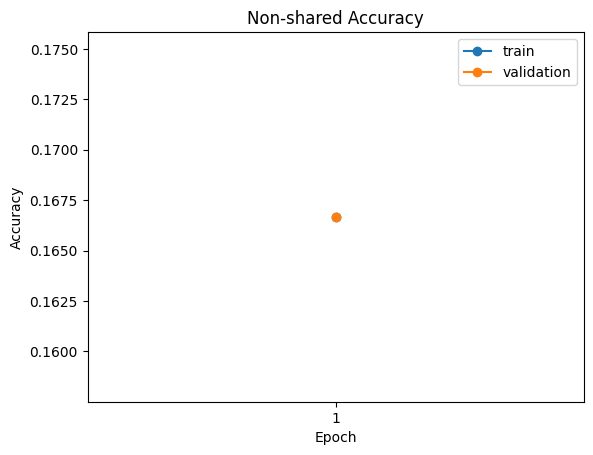

In [90]:
import json
import matplotlib.pyplot as plt

path = "artifacts/cnn/histories/cnn_c2_f32-64_k3-3_max_non_shared.json"

with open(path) as f:
    hist = json.load(f)

epochs = range(1, len(hist["loss"]) + 1)

plt.figure()
plt.plot(epochs, hist["loss"], marker="o", label="train")
plt.plot(epochs, hist["val_loss"], marker="o", label="validation")
plt.title("Non-shared Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, hist["accuracy"], marker="o", label="train")
plt.plot(epochs, hist["val_accuracy"], marker="o", label="validation")
plt.title("Non-shared Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.show()

## Save Artifacts

In [91]:
### Zip Artifacts

!zip -r cnn_report_assets.zip \
  artifacts/cnn/plots \
  artifacts/cnn/metrics \
  artifacts/cnn/histories

  adding: artifacts/cnn/plots/ (stored 0%)
  adding: artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_max.png (deflated 10%)
  adding: artifacts/cnn/plots/cnn_c2_f32-64_k5-3_average.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c2_f64-128_k5-3_average.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c2_f64-128_k3-3_average.png (deflated 8%)
  adding: artifacts/cnn/plots/cnn_c3_f64-128-256_k3-3-3_average.png (deflated 8%)
  adding: artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max_non_shared.png (deflated 19%)
  adding: artifacts/cnn/plots/cnn_c2_f64-128_k3-3_max.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c2_f32-64_k3-3_max.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c2_f64-128_k5-3_max.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c3_f32-64-128_k3-3-3_max.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c2_f32-64_k5-3_max.png (deflated 9%)
  adding: artifacts/cnn/plots/cnn_c3_f64-128-256_k5-3-3_average.png (deflated 8%)
  adding: artifacts/cnn/plots/cnn_c3_f32-

In [92]:
from google.colab import files
files.download("cnn_report_assets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>